In [1]:
import numpy as np
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
from utils import run_logit, split_test_train

In [2]:
# fetch dataset 
asdf = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = asdf.data.features.to_numpy()
y = asdf.data.targets.to_numpy().ravel()

In [23]:
# Setup
random_state=237
num_iter=100
rng=np.random.default_rng(random_state)
kappa_values=np.linspace(0,3,35)[1:]
p_values=np.arange(1,31)
n=250
kappas = p_values/n

In [24]:
print(kappas)

[0.004 0.008 0.012 0.016 0.02  0.024 0.028 0.032 0.036 0.04  0.044 0.048
 0.052 0.056 0.06  0.064 0.068 0.072 0.076 0.08  0.084 0.088 0.092 0.096
 0.1   0.104 0.108 0.112 0.116 0.12 ]


c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\lando\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://s

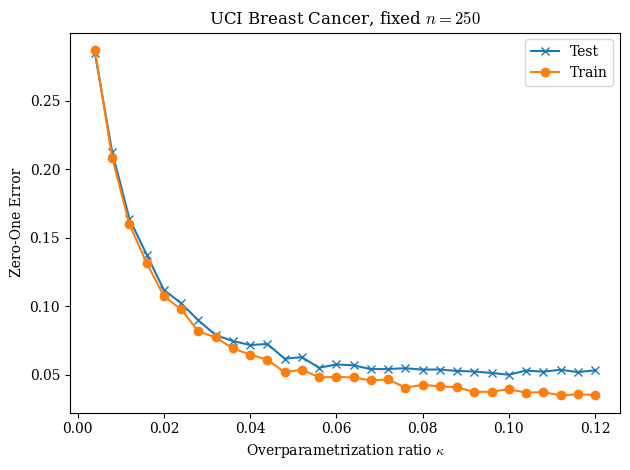

In [25]:
train_errors=[]
test_errors=[]
for p_idx,p in enumerate(p_values):
    listy_test=np.zeros(num_iter)
    listy_train=np.zeros(num_iter)
    for t in range(num_iter):
        X_train, y_train, X_test, y_test, _ = split_test_train(X,y,p,n,rng)
        errors = run_logit(X_train,y_train,X_test,y_test)
        listy_train[t]=(errors["train_error"])
        listy_test[t]=(errors["test_error"])
    train_errors.append(np.mean(listy_train))
    test_errors.append(np.mean(listy_test))
    
plt.rcParams.update({'font.family': 'serif','mathtext.fontset': 'cm',})

plt.plot(kappas,test_errors,marker='x',label='Test')
plt.plot(kappas,train_errors,marker='o',label='Train')
plt.ylabel('Zero-One Error')
plt.xlabel(r'Overparametrization ratio $\kappa$')
plt.title(f'UCI Breast Cancer, fixed $n={n}$')
plt.legend()
plt.tight_layout()
plt.savefig(f'breast_cancer_kappa_n={n}.png',dpi=400)
